# 23 · KNN — Sesgo, Varianza y el *Sweet Spot* de K

**Reto práctico:** entrenar un clasificador KNN sobre `loan_data` (PSDS) para distintos valores de K
y descubrir, con **5-fold cross-validation**, el K que minimiza el error.

Esperamos una **curva en U**:

| K | Comportamiento | Sesgo | Varianza |
|---|---|---|---|
| **1** | Memoriza el ruido (overfit) | Bajo | **Alta** — desv. entre folds grande |
| **K\*** | *Sweet spot* — error mínimo | Equilibrio | Equilibrio |
| **K muy grande** | Predice la clase mayoritaria (underfit) | **Alto** — error alto consistente | Baja |

Validamos esa intuición midiendo, para cada K, el **error promedio** y la **desviación estándar entre folds**.

> **Nota sobre el grid de K:** el reto sugiere K ∈ {1, 3, 5, 10, 20, 50, 100, 200}. Como `loan_data` tiene
> 3 000 filas, K=200 todavía es un vecindario *local* (≈ 7 % de los datos) y no fuerza alto sesgo.
> Extendemos el grid hasta K=2 000 para que la "U" sea visible en ambos extremos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(42)

## 1 · Cargar `loan_data` (PSDS)

Dataset real de préstamos del libro *Practical Statistics for Data Scientists*.
Tarea: predecir si un préstamo cae en `default` o se paga (`paid off`).

| Columna | Significado |
|---|---|
| `borrower_score` | Score crediticio normalizado (0–1, mayor = mejor pagador) |
| `payment_inc_ratio` | Cuota mensual / ingreso mensual (mayor = préstamo más pesado) |
| `outcome` | Target binario: `default` vs `paid off` |

Sólo 2 features → podemos visualizar la frontera de decisión en 2D.

In [4]:
DATA = Path("../data/loans.csv")
df = pd.read_csv(DATA)

df["y"] = (df["outcome"] == "default").astype(int)
FEATURES = ["borrower_score", "payment_inc_ratio"]
X = df[FEATURES].to_numpy()
y = df["y"].to_numpy()

print(f"Filas         : {len(df):,}")
print(f"Default   (1) : {(y == 1).sum():,}  ({y.mean():.1%})")
print(f"Paid off  (0) : {(y == 0).sum():,}  ({1 - y.mean():.1%})")
df.head()

Task was destroyed but it is pending!
task: <Task pending name='Task-90' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-91' coro=<Kernel.shell_main() running at /Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
<frozen abc>:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
Task was destroyed but it is pending!
task: <Task pending name='Task-91' coro=<Kernel.shell_main() running at /Users/angelozdev/me/practical-statistics-for-data-analysis/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup(

Filas         : 3,000
Default   (1) : 1,350  (45.0%)
Paid off  (0) : 1,650  (55.0%)


,borrower_score,payment_inc_ratio,outcome,y
0,0.451,5.83,default,1
1,0.632,7.82,paid off,0
2,0.308,17.27,default,1
3,0.653,7.85,paid off,0
4,0.398,15.38,default,1


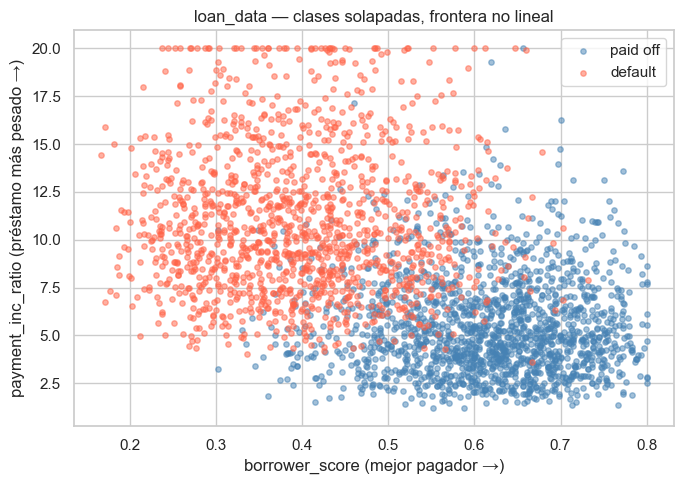

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for cls, color, label in [(0, "steelblue", "paid off"), (1, "tomato", "default")]:
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.5, color=color, label=label)
ax.set_xlabel("borrower_score (mejor pagador →)")
ax.set_ylabel("payment_inc_ratio (préstamo más pesado →)")
ax.set_title("loan_data — clases solapadas, frontera no lineal")
ax.legend()
plt.tight_layout()
plt.show()

## 2 · Setup del experimento

**KNN exige escalado.** La distancia euclidiana mezcla `borrower_score` (0–1) con
`payment_inc_ratio` (~0–30); sin estandarizar, la segunda variable domina. Metemos
`StandardScaler` dentro del **pipeline** para que el `fit` use sólo el train de cada fold
(sin *data leakage*).

- **K grid:** {1, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 2000}
- **CV:** `StratifiedKFold` con 5 folds (mantiene proporción de `default` en cada fold)
- **Métrica:** error de clasificación = `1 − accuracy`

In [6]:
K_VALUES = [1, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

records = []
for k in K_VALUES:
    pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    err = 1.0 - acc
    records.append(
        {
            "K": k,
            "error_mean": err.mean(),
            "error_std": err.std(ddof=1),
            "errors": err,
        }
    )

results = pd.DataFrame(records)
results_view = results[["K", "error_mean", "error_std"]].copy()
results_view["error_mean"] = results_view["error_mean"].round(4)
results_view["error_std"] = results_view["error_std"].round(4)
results_view

,K,error_mean,error_std
0,1,0.1337,0.0206
1,3,0.1077,0.0116
2,5,0.1017,0.0096
3,10,0.0973,0.0144
4,20,0.0927,0.0122
5,50,0.0910,0.0145
6,100,0.0927,0.0104
7,200,0.0917,0.0087
8,500,0.0903,0.0077
9,1000,0.0947,0.0076


## 3 · Curva en U — error vs K

Eje X **logarítmico** (los Ks crecen multiplicativamente). Las barras de error muestran la
dispersión entre los 5 folds: más grandes = predicción menos estable.

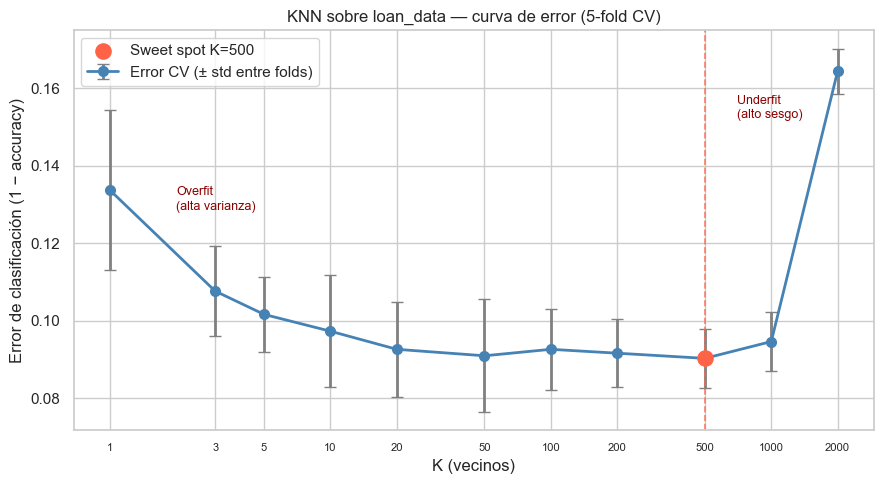

Sweet spot: K = 500  |  error = 0.0903  |  std = 0.0077


In [7]:
best_idx = results["error_mean"].idxmin()
best_k = int(results.loc[best_idx, "K"])
best_err = results.loc[best_idx, "error_mean"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    results["K"],
    results["error_mean"],
    yerr=results["error_std"],
    marker="o",
    markersize=7,
    capsize=4,
    color="steelblue",
    ecolor="gray",
    linewidth=2,
    label="Error CV (± std entre folds)",
)
ax.axvline(best_k, color="tomato", linestyle="--", linewidth=1.2, alpha=0.8)
ax.scatter([best_k], [best_err], color="tomato", s=120, zorder=5, label=f"Sweet spot K={best_k}")
ax.set_xscale("log")
ax.set_xticks(K_VALUES)
ax.set_xticklabels(K_VALUES, rotation=0, fontsize=8)
ax.set_xlabel("K (vecinos)")
ax.set_ylabel("Error de clasificación (1 − accuracy)")
ax.set_title("KNN sobre loan_data — curva de error (5-fold CV)")
ax.legend()

ax.annotate(
    "Overfit\n(alta varianza)",
    xy=(K_VALUES[0], results["error_mean"].iloc[0]),
    xytext=(2, results["error_mean"].iloc[0] - 0.005),
    fontsize=9,
    color="darkred",
)
ax.annotate(
    "Underfit\n(alto sesgo)",
    xy=(K_VALUES[-1], results["error_mean"].iloc[-1]),
    xytext=(700, results["error_mean"].iloc[-1] - 0.012),
    fontsize=9,
    color="darkred",
)

plt.tight_layout()
plt.show()

print(f"Sweet spot: K = {best_k}  |  error = {best_err:.4f}  |  std = {results.loc[best_idx, 'error_std']:.4f}")

## 4 · Diagnóstico de extremos

Comparamos **K=1** (extremo *high variance*) vs **K=2000** (extremo *high bias*) contra el sweet spot.

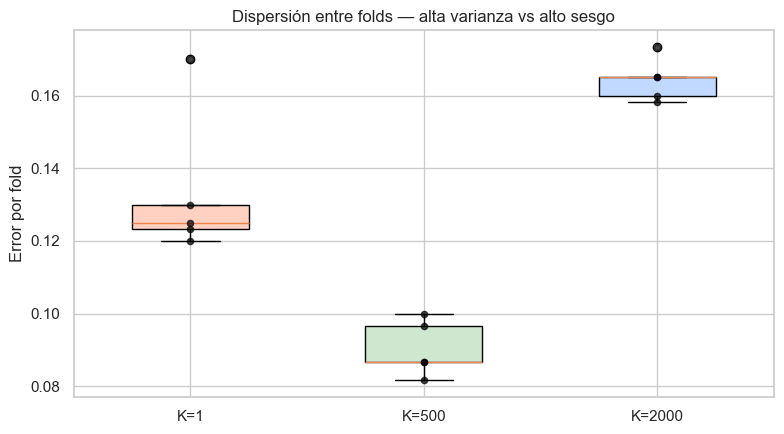

Diagnóstico:
  K=   1  →  error = 0.1337  |  std entre folds = 0.0206
  K= 500  →  error = 0.0903  |  std entre folds = 0.0077
  K=2000  →  error = 0.1643  |  std entre folds = 0.0058


In [8]:
def diagnose(k):
    row = results[results["K"] == k].iloc[0]
    return row["error_mean"], row["error_std"], row["errors"]


extremes = [1, best_k, 2000]
fig, ax = plt.subplots(figsize=(8, 4.5))

positions = np.arange(len(extremes))
fold_errors = [diagnose(k)[2] for k in extremes]

bp = ax.boxplot(fold_errors, positions=positions, widths=0.5, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#ffd1c2", "#cfe6cf", "#c2d9ff"]):
    patch.set_facecolor(color)

for i, k in enumerate(extremes):
    ax.scatter([i] * 5, fold_errors[i], color="black", s=20, zorder=5, alpha=0.7)

ax.set_xticks(positions)
ax.set_xticklabels([f"K={k}" for k in extremes])
ax.set_ylabel("Error por fold")
ax.set_title("Dispersión entre folds — alta varianza vs alto sesgo")
plt.tight_layout()
plt.show()

print("Diagnóstico:")
for k in extremes:
    m, s, _ = diagnose(k)
    print(f"  K={k:>4}  →  error = {m:.4f}  |  std entre folds = {s:.4f}")

### Lectura del boxplot

- **K=1 — alta varianza:** caja ancha, std grande. Cada fold ve un "mapa" distinto del ruido y
  produce un error distinto. El modelo memoriza vecinos individuales.
- **K\* (sweet spot):** caja estrecha, error bajo. Estable y preciso.
- **K=2000 — alto sesgo:** caja estrecha **pero error alto**. El modelo promedia tantos vecinos que
  predice casi siempre la clase mayoritaria (`paid off`). Consistente porque siempre se equivoca igual.

## 5 · Fronteras de decisión — ver el sesgo y la varianza

La curva en U se entiende mejor visualizando lo que cada K **dibuja** sobre el espacio de features.

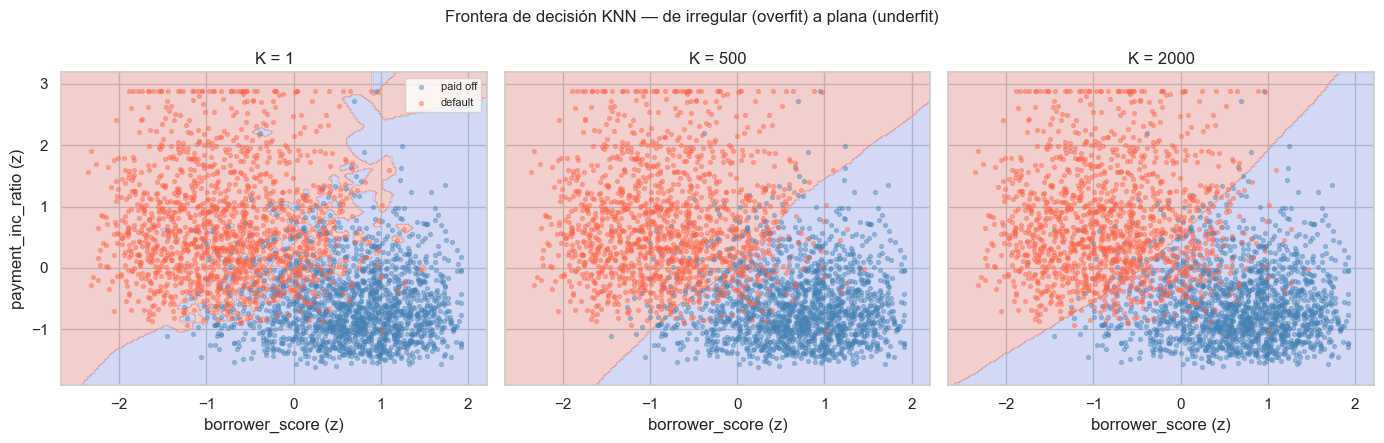

In [9]:
scaler_full = StandardScaler().fit(X)
X_s = scaler_full.transform(X)

x0 = np.linspace(X_s[:, 0].min() - 0.3, X_s[:, 0].max() + 0.3, 200)
x1 = np.linspace(X_s[:, 1].min() - 0.3, X_s[:, 1].max() + 0.3, 200)
xx, yy = np.meshgrid(x0, x1)
grid = np.c_[xx.ravel(), yy.ravel()]

ks_to_plot = [1, best_k, 2000]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)

for ax, k in zip(axes, ks_to_plot):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_s, y)
    Z = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(
        X_s[y == 0, 0], X_s[y == 0, 1], s=8, alpha=0.4, color="steelblue", label="paid off"
    )
    ax.scatter(
        X_s[y == 1, 0], X_s[y == 1, 1], s=8, alpha=0.4, color="tomato", label="default"
    )
    ax.set_title(f"K = {k}")
    ax.set_xlabel("borrower_score (z)")
axes[0].set_ylabel("payment_inc_ratio (z)")
axes[0].legend(loc="upper right", fontsize=8)

plt.suptitle("Frontera de decisión KNN — de irregular (overfit) a plana (underfit)", fontsize=12)
plt.tight_layout()
plt.show()

## Resumen

1. **Curva en U confirmada en datos reales.** `loan_data` muestra error alto en K=1 (overfit) y en K=2000 (underfit); mínimo en el medio.
2. **Sweet spot encontrado por CV**, no a ojo. `cross_val_score` + `StratifiedKFold` dan media y std por fold.
3. **K=1 → alta varianza:** std entre folds grande — el modelo es inestable, depende del ruido del train.
4. **K=2000 → alto sesgo:** error alto consistente — frontera demasiado plana, ignora la señal y predice siempre `paid off`.
5. **Pipeline con StandardScaler dentro de CV** evita data leakage; el scaler se ajusta sólo con el train de cada fold.
6. **El grid de K depende del tamaño del dataset.** Con n=3 000, K=200 todavía es local. Para ver alto sesgo hay que llegar a K cercano a n.

> **Regla práctica:** elige el K más grande cuyo error siga dentro de **1 std** del mínimo (*1-SE rule*).
> Penaliza modelos más complejos cuando la mejora es ruido.